# 🧪 01 - Exploratory Data Analysis (EDA)
This notebook explores the UCI Diabetes 130-Hospitals dataset to understand the features,
target distribution, and potential issues like missing data or class imbalance.

**Goals:**
- Understand the structure of the data
- Identify missing or problematic values
- Explore relationships between features and readmission status

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style='whitegrid')

In [2]:
# Load the dataset
data_path = '../data/diabetic_data.csv'  # adjust path if needed
df = pd.read_csv(data_path)
df.shape

(101766, 50)

## 🔍 Basic Dataset Overview

In [3]:
# Show the first few rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Check for null values
df.isnull().sum().sort_values(ascending=False).head(20)

max_glu_serum               96420
A1Cresult                   84748
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
encounter_id                    0
patient_nbr                     0
number_inpatient                0
number_emergency                0
dtype: int64

## 🎯 Target Variable Analysis

In [5]:
# Analyze target variable (e.g., 'readmitted')
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [6]:
# Optional: Convert to binary classification if needed
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df['readmitted_binary'].value_counts(normalize=True)

readmitted_binary
0    0.888401
1    0.111599
Name: proportion, dtype: float64

### 📊 Visualizing Target Variable Distribution
Bar plots to visualize the class distribution of the `readmitted` variable.

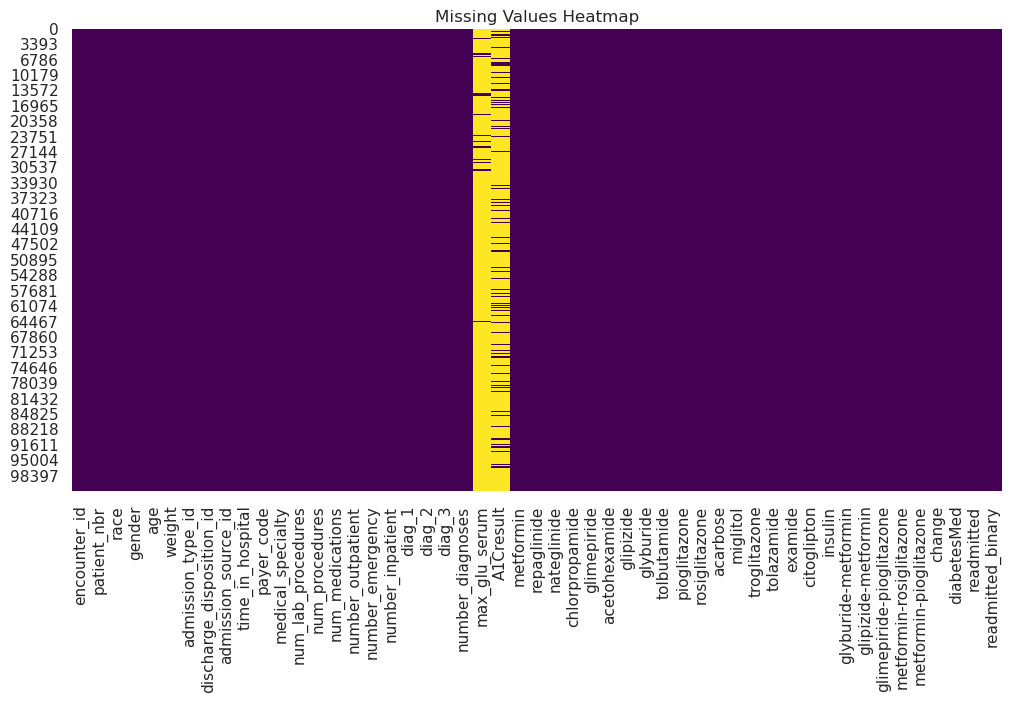

In [7]:
# Visualize missing values (if any are NaN)
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
# Plot top 10 most common admission types
plt.figure(figsize=(10, 5))
sns.countplot(y='admission_type_id', data=df, order=df['admission_type_id'].value_counts().index)
plt.title('Admission Type Distribution')
plt.xlabel('Count')
plt.ylabel('Admission Type')
plt.show()

## 📊 Feature Distribution & Cleaning
- Visualize top categorical columns
- Drop or encode high-cardinality fields
- Remove columns with too many missing or meaningless values